# Part A - Data Loading and Preprocessing with Scikit-learn

## Task 1 - Load and Understand the Dataset

In [ ]:
import pandas as pd
from tabulate import tabulate

# Load the dataset
df = pd.read_csv('hotel_bookings.csv')

# head()
print("HEAD (first 5 rows, transposed for readability)")
print(tabulate(df.head().T, headers=['Column'] + [f'Row {i}' for i in range(5)], tablefmt='grid'))

# shape
print(f"\nShape: {df.shape[0]} rows, {df.shape[1]} columns")

# info()
print("\nInfo:")
df.info()

# describe()
print("\nDESCRIBE (numerical summary)")
print(tabulate(df.describe(), headers='keys', tablefmt='grid'))

# dtypes
print("\nDTYPES")
dtypes_df = df.dtypes.reset_index()
dtypes_df.columns = ['Column', 'Dtype']
print(tabulate(dtypes_df, headers='keys', tablefmt='grid', showindex=False))

# Class distribution of is_canceled
print("\nCLASS DISTRIBUTION of is_canceled")
dist_df = df['is_canceled'].value_counts().reset_index()
dist_df.columns = ['is_canceled', 'Count']
print(tabulate(dist_df, headers='keys', tablefmt='grid', showindex=False))

# Target
y = df['is_canceled']

# X from remaining usable features (drop target + leakage columns)
leakage_cols = ['reservation_status', 'reservation_status_date']
X = df.drop(columns=['is_canceled'] + leakage_cols)

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

max_len = max(len(numerical_cols), len(categorical_cols))
cols_df = pd.DataFrame({
    'Numerical': numerical_cols + [''] * (max_len - len(numerical_cols)),
    'Categorical': categorical_cols + [''] * (max_len - len(categorical_cols))
})
print(f"\nFEATURE TYPES ({len(numerical_cols)} numerical, {len(categorical_cols)} categorical)")
print(tabulate(cols_df, headers='keys', tablefmt='grid', showindex=False))

HEAD (first 5 rows, transposed for readability)
+--------------------------------+--------------+--------------+--------------+--------------+--------------+
| Column                         | Row 0        | Row 1        | Row 2        | Row 3        | Row 4        |
+================================+==============+==============+==============+==============+==============+
| hotel                          | Resort Hotel | Resort Hotel | Resort Hotel | Resort Hotel | Resort Hotel |
+--------------------------------+--------------+--------------+--------------+--------------+--------------+
| is_canceled                    | 0            | 0            | 0            | 0            | 0            |
+--------------------------------+--------------+--------------+--------------+--------------+--------------+
| lead_time                      | 342          | 737          | 7            | 13           | 14           |
+--------------------------------+--------------+--------------+--------

## Task 2

MISSING VALUES
+----------+-----------------+-------------+
| Column   |   Missing Count |   Missing % |
+==========+=================+=============+
| company  |          112593 |       94.31 |
+----------+-----------------+-------------+
| agent    |           16340 |       13.69 |
+----------+-----------------+-------------+
| country  |             488 |        0.41 |
+----------+-----------------+-------------+
| children |               4 |        0    |
+----------+-----------------+-------------+

Dropped 'company' (94.3% missing) — too sparse to impute reliably.
Dropped 'reservation_status' and 'reservation_status_date' (leakage — directly encode the target).


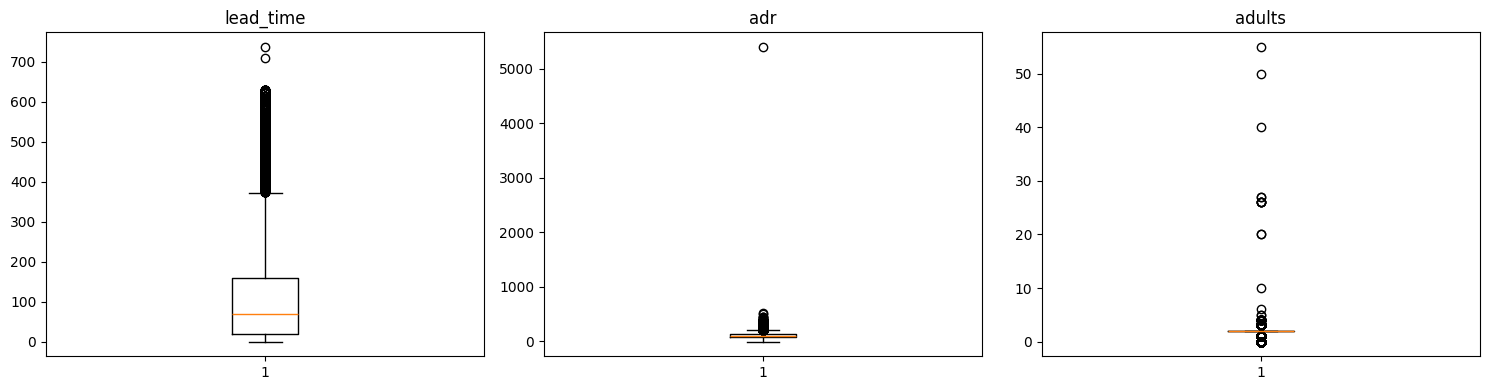


IQR OUTLIER SUMMARY
+-----------+-------------+-------------+------------------+
| Column    |   IQR Lower |   IQR Upper |   Flagged by IQR |
+===========+=============+=============+==================+
| lead_time |     -195    |      373    |             3005 |
+-----------+-------------+-------------+------------------+
| adr       |      -15.77 |      211.06 |             3793 |
+-----------+-------------+-------------+------------------+
| adults    |        2    |        2    |            29710 |
+-----------+-------------+-------------+------------------+

Rows before outlier removal: 119390
Rows after outlier removal:  118973
Rows removed: 417 (0.349%)


In [36]:

import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

# ---------------------------------------------------------
# 1. Missing-value count and percentage for every column
# ---------------------------------------------------------
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("MISSING VALUES")
print(tabulate(missing_df.reset_index().rename(columns={'index': 'Column'}), headers='keys', tablefmt='grid', showindex=False))

# ---------------------------------------------------------
# 2. Identify and drop columns with very high missingness
# ---------------------------------------------------------
# 'company' is missing ~94% of values. This isn't "sparse but usable" —
# at that level, any imputation would be fabricating the vast majority
# of the column, so it's dropped rather than imputed.
# 'agent' (~14% missing) and 'country' (~0.4%) are kept — low enough
# to impute later (e.g. mode/constant) without dominating the column.
df = df.drop(columns=['company'])
print("\nDropped 'company' (94.3% missing) — too sparse to impute reliably.")

# ---------------------------------------------------------
# 3. Remove columns that directly reveal the outcome (leakage)
# ---------------------------------------------------------
# reservation_status is essentially a restatement of is_canceled
# (e.g. 'Canceled' / 'Check-Out' / 'No-Show'), and reservation_status_date
# is the date tied to that outcome. Keeping either would let the model
# "cheat" by reading the answer directly.
df = df.drop(columns=['reservation_status', 'reservation_status_date'])
print("Dropped 'reservation_status' and 'reservation_status_date' (leakage — directly encode the target).")

# ---------------------------------------------------------
# 4. Check selected numerical features for outliers (boxplot + IQR)
# ---------------------------------------------------------
outlier_check_cols = ['lead_time', 'adr', 'adults']

fig, axes = plt.subplots(1, len(outlier_check_cols), figsize=(15, 4))
for ax, col in zip(axes, outlier_check_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.savefig('outlier_boxplots.png')
plt.show()

iqr_summary = []
for col in outlier_check_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_flagged = ((df[col] < low) | (df[col] > high)).sum()
    iqr_summary.append([col, round(low, 2), round(high, 2), n_flagged])

iqr_df = pd.DataFrame(iqr_summary, columns=['Column', 'IQR Lower', 'IQR Upper', 'Flagged by IQR'])
print("\nIQR OUTLIER SUMMARY")
print(tabulate(iqr_df, headers='keys', tablefmt='grid', showindex=False))

# ---------------------------------------------------------
# 5. Remove only clear/extreme outliers (data errors, not just
#    statistically distant points) and report rows removed
# ---------------------------------------------------------
# adr: a negative rate is not a valid price (data entry error).
#      A single-night rate of 5400 is also implausible vs a median ~95 —
#      kept as an extreme cutoff rather than the tighter IQR bound.
# adults: bookings with 0 adults, or an implausible number of adults (>10)
#         on one reservation, are almost certainly data entry errors.
before = len(df)

df = df[(df['adr'] >= 0) & (df['adr'] < 5000)]
df = df[(df['adults'] > 0) & (df['adults'] <= 10)]

after = len(df)
print(f"\nRows before outlier removal: {before}")
print(f"Rows after outlier removal:  {after}")
print(f"Rows removed: {before - after} ({(before - after) / before * 100:.3f}%)")

In [37]:
output_file_path = 'cleaned_hotel_bookings.csv'
df.to_csv(output_file_path, index=False)
print(f"Cleaned dataset saved to '{output_file_path}'")

Cleaned dataset saved to 'cleaned_hotel_bookings.csv'


## Task 3

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3))

X_train shape: (95512, 29)
X_test shape: (23878, 29)

Train class balance:
 is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64

Test class balance:
 is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


In [ ]:
# 1. Column types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

# 2. Imports
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# 3. Categorical branch (SimpleImputer + OneHotEncoder)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 4. Numerical branch — Pipeline A (KNNImputer + StandardScaler)
numerical_transformer_A = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

# 5. Numerical branch — Pipeline B (KNNImputer + MinMaxScaler)
numerical_transformer_B = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

# 6. Fast copies of train/test (float32 for speed)
X_train_fast = X_train.copy()
X_train_fast[numerical_cols] = X_train_fast[numerical_cols].astype('float32')

X_test_fast = X_test.copy()
X_test_fast[numerical_cols] = X_test_fast[numerical_cols].astype('float32')

# 7. Merge into full preprocessors
preprocessor_A = ColumnTransformer(transformers=[
    ('num', numerical_transformer_A, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

preprocessor_B = ColumnTransformer(transformers=[
    ('num', numerical_transformer_B, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

Numerical columns: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [ ]:
import time

start = time.time()
X_train_A = preprocessor_A.fit_transform(X_train_fast)
print("Done. Took", round(time.time() - start, 1), "seconds")
print("Shape:", X_train_A.shape)

Done. Took 531.7 seconds
Shape: (95512, 252)


In [ ]:
start = time.time()
X_test_A = preprocessor_A.transform(X_test_fast)
print("Test transform took", round(time.time() - start, 1), "seconds")
print("Shape:", X_test_A.shape)

Test transform took 129.7 seconds
Shape: (23878, 252)


In [ ]:
start = time.time()
X_train_B = preprocessor_B.fit_transform(X_train_fast)
print("Done. Took", round(time.time() - start, 1), "seconds")
print("Shape:", X_train_B.shape)

Done. Took 519.6 seconds
Shape: (95512, 252)


In [22]:
start = time.time()
X_test_B = preprocessor_B.transform(X_test_fast)
print("Test transform took", round(time.time() - start, 1), "seconds")
print("Shape:", X_test_B.shape)

Test transform took 147.7 seconds
Shape: (23878, 252)


# Part B - Model Training and Performance Evaluation

## Task 4

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Combination 1: LogisticRegression + Pipeline A
model_1 = Pipeline(steps=[
    ('preprocessor', preprocessor_A),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Combination 2: LogisticRegression + Pipeline B
model_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_B),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Combination 3: DecisionTreeClassifier + Pipeline A
model_3 = Pipeline(steps=[
    ('preprocessor', preprocessor_A),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Combination 4: DecisionTreeClassifier + Pipeline B
model_4 = Pipeline(steps=[
    ('preprocessor', preprocessor_B),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [23]:
# Faster: train directly on already-preprocessed data from Task 3
print("Training Model 1 (LogisticRegression on Pipeline A output)...")
log_reg_A = LogisticRegression(max_iter=1000)
log_reg_A.fit(X_train_A, y_train)

print("Training Model 2 (LogisticRegression on Pipeline B output)...")
log_reg_B = LogisticRegression(max_iter=1000)
log_reg_B.fit(X_train_B, y_train)

print("Training Model 3 (DecisionTree on Pipeline A output)...")
tree_A = DecisionTreeClassifier(random_state=42)
tree_A.fit(X_train_A, y_train)

print("Training Model 4 (DecisionTree on Pipeline B output)...")
tree_B = DecisionTreeClassifier(random_state=42)
tree_B.fit(X_train_B, y_train)

Training Model 1 (LogisticRegression on Pipeline A output)...
Training Model 2 (LogisticRegression on Pipeline B output)...
Training Model 3 (DecisionTree on Pipeline A output)...
Training Model 4 (DecisionTree on Pipeline B output)...


DecisionTreeClassifier(random_state=42)

## Task 5

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_train_proc, X_test_proc, y_train, y_test, name):
    train_pred = model.predict(X_train_proc)
    test_pred = model.predict(X_test_proc)

    results = {
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Precision': precision_score(y_test, test_pred),
        'Recall': recall_score(y_test, test_pred),
        'F1-Score': f1_score(y_test, test_pred)
    }
    return results

results_list = []

results_list.append(evaluate_model(log_reg_A, X_train_A, X_test_A, y_train, y_test, 'LogisticRegression + Pipeline A'))
results_list.append(evaluate_model(log_reg_B, X_train_B, X_test_B, y_train, y_test, 'LogisticRegression + Pipeline B'))
results_list.append(evaluate_model(tree_A, X_train_A, X_test_A, y_train, y_test, 'DecisionTree + Pipeline A'))
results_list.append(evaluate_model(tree_B, X_train_B, X_test_B, y_train, y_test, 'DecisionTree + Pipeline B'))

In [27]:
import pandas as pd
from tabulate import tabulate

comparison_df = pd.DataFrame(results_list)
comparison_df = comparison_df.round(4)

print("FINAL COMPARISON TABLE")
print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))

FINAL COMPARISON TABLE
+---------------------------------+------------------+-----------------+-------------+----------+------------+
| Model                           |   Train Accuracy |   Test Accuracy |   Precision |   Recall |   F1-Score |
+=================================+==================+=================+=============+==========+============+
| LogisticRegression + Pipeline A |           0.8185 |          0.8192 |      0.8116 |   0.6666 |     0.732  |
+---------------------------------+------------------+-----------------+-------------+----------+------------+
| LogisticRegression + Pipeline B |           0.8136 |          0.8146 |      0.8094 |   0.6535 |     0.7231 |
+---------------------------------+------------------+-----------------+-------------+----------+------------+
| DecisionTree + Pipeline A       |           0.9963 |          0.8567 |      0.8052 |   0.8089 |     0.8071 |
+---------------------------------+------------------+-----------------+-------------+---

In [28]:
lr_rows = comparison_df[comparison_df['Model'].str.contains('LogisticRegression')]
tree_rows = comparison_df[comparison_df['Model'].str.contains('DecisionTree')]

best_lr_name = lr_rows.loc[lr_rows['F1-Score'].idxmax(), 'Model']
best_tree_name = tree_rows.loc[tree_rows['F1-Score'].idxmax(), 'Model']

print("Best Logistic Regression:", best_lr_name)
print("Best Decision Tree:", best_tree_name)

Best Logistic Regression: LogisticRegression + Pipeline A
Best Decision Tree: DecisionTree + Pipeline A


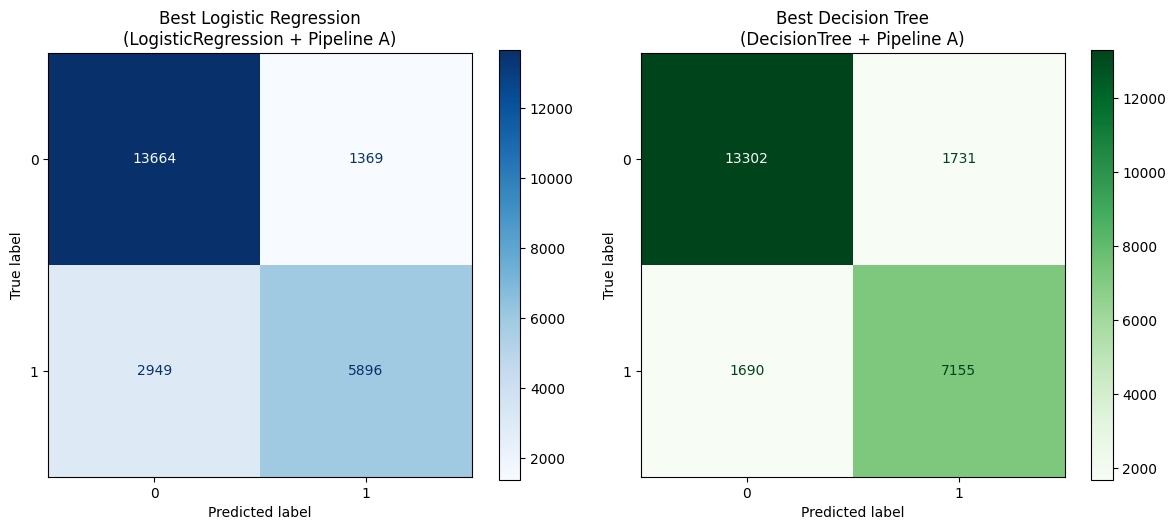

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Map model names back to their actual trained objects + preprocessed test data
model_lookup = {
    'LogisticRegression + Pipeline A': (log_reg_A, X_test_A),
    'LogisticRegression + Pipeline B': (log_reg_B, X_test_B),
    'DecisionTree + Pipeline A': (tree_A, X_test_A),
    'DecisionTree + Pipeline B': (tree_B, X_test_B)
}

best_lr_model, best_lr_Xtest = model_lookup[best_lr_name]
best_tree_model, best_tree_Xtest = model_lookup[best_tree_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(best_lr_model, best_lr_Xtest, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title(f'Best Logistic Regression\n({best_lr_name})')

ConfusionMatrixDisplay.from_estimator(best_tree_model, best_tree_Xtest, y_test, ax=axes[1], cmap='Greens')
axes[1].set_title(f'Best Decision Tree\n({best_tree_name})')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

In [30]:
comparison_df['Train-Test Gap'] = (comparison_df['Train Accuracy'] - comparison_df['Test Accuracy']).round(4)
print(tabulate(comparison_df[['Model', 'Train Accuracy', 'Test Accuracy', 'Train-Test Gap']],
               headers='keys', tablefmt='grid', showindex=False))

print("\nOverfitting notes:")
for _, row in comparison_df.iterrows():
    gap = row['Train-Test Gap']
    if gap > 0.05:
        note = "noticeable gap — possible overfitting"
    elif gap > 0.02:
        note = "small gap — mild overfitting, likely acceptable"
    else:
        note = "minimal gap — generalizes well"
    print(f"- {row['Model']}: gap = {gap:.4f} → {note}")

+---------------------------------+------------------+-----------------+------------------+
| Model                           |   Train Accuracy |   Test Accuracy |   Train-Test Gap |
+=================================+==================+=================+==================+
| LogisticRegression + Pipeline A |           0.8185 |          0.8192 |          -0.0007 |
+---------------------------------+------------------+-----------------+------------------+
| LogisticRegression + Pipeline B |           0.8136 |          0.8146 |          -0.001  |
+---------------------------------+------------------+-----------------+------------------+
| DecisionTree + Pipeline A       |           0.9963 |          0.8567 |           0.1396 |
+---------------------------------+------------------+-----------------+------------------+
| DecisionTree + Pipeline B       |           0.9963 |          0.8566 |           0.1397 |
+---------------------------------+------------------+-----------------+--------